<a href="https://colab.research.google.com/github/ishancoderr/3D_modeling/blob/main/agent_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hello world Agent

In [3]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [4]:
class AgentState(TypedDict):
  message: str

def greeting_node(state: AgentState) -> AgentState:
  state['message'] = "Hello "+ state["message"] + ", how is your day is going"
  return state



In [7]:
graph = StateGraph(AgentState)
graph.add_node("greeter", greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

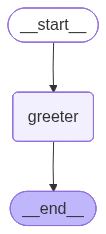

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
app.invoke({"message":"Bob"})

{'message': 'Hello Bob, how is your day is going'}

Multiple Input Graph

In [46]:
from typing import List
from langgraph.graph import StateGraph

In [52]:
class AgentState(TypedDict):
  values:List[int]
  name:str
  result:str

In [53]:
def process_values(state:AgentState) -> AgentState:
  state['result'] = f"HI there {state["name"]}! Your sum = {sum(state["values"])}"
  return state

In [49]:
graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()



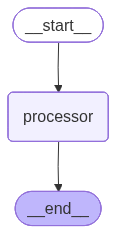

In [54]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [55]:
app.invoke({"values":[1,2,3,4] ,"name":"ishan"})

{'values': [1, 2, 3, 4], 'name': 'ishan'}
{'values': [1, 2, 3, 4], 'name': 'ishan', 'result': 'HI there ishan! Your sum = 10'}


{'values': [1, 2, 3, 4],
 'name': 'ishan',
 'result': 'HI there ishan! Your sum = 10'}